# SVM-set benefit on a 100-feature synthetic dataset

This experiment repeats the fixed-blind-set comparison on synthetic binary
classification data with 100 features and known signal structure. It compares
forward- and backward-selected MiSTIC SVM sets with conventional sklearn
RBF SVM references and a known-signal oracle upper bound while varying the
number of ensemble members.

All methods are evaluated on the same untouched blind set. The data generator
places 10 informative features first, followed by 10 redundant features and
80 noise features (`shuffle=False`), allowing selected-feature recovery to be
measured in addition to predictive performance.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Make the notebook work from either the repository root or validation.
repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "mistic" / "svmSet.py").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svc, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

Matplotlib is building the font cache; this may take a moment.


## Experimental design

The dataset contains 500 observations and 100 predictors: 10 informative, 10
redundant, and 80 noise features. A fixed stratified 25% blind set is withheld
before scaling, tuning, selection, or cutoff calibration.

The default MiSTIC approach shown here is **knee-selected**. Both forward and
backward searches use `combined_rank(weight=0.75)`, separate feature sets, and
separate parameters for every member. Search uses scaled gamma with
`tune_models_each_step=False`; after `find_knee()` chooses the feature count,
the knee subset is retuned with the complete parameter grid.

Forward search uses the optimized 20-medoid singleton screen and caps each
member at 20 features. Backward search begins with all 100 features. Ensemble
sizes are 1, 3, 5, 10, 20, 30, 40, and 50. All expensive knee searches are
cached by standalone extension notebooks and merged here.

In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))

X_values, y_values = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=N_INFORMATIVE,
    n_redundant=N_REDUNDANT,
    n_repeated=0,
    n_classes=2,
    weights=[0.55, 0.45],
    class_sep=1.0,
    flip_y=0.03,
    shuffle=False,
    random_state=2026,
)
feature_names = [
    *(f"informative_{i:02d}" for i in range(N_INFORMATIVE)),
    *(f"redundant_{i:02d}" for i in range(N_REDUNDANT)),
    *(f"noise_{i:02d}" for i in range(N_FEATURES - N_INFORMATIVE - N_REDUNDANT)),
]
X = pd.DataFrame(X_values, columns=feature_names)
y = pd.Series(y_values, name="class")

MODEL_COUNTS = [1, 3, 5, 10, 20, 30, 40, 50]
BLIND_SET_SEED = 42
INNER_SEEDS = list(range(3))
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
RANK_WEIGHT = 0.75
SELECTION_STRATEGIES = ["backward"]

# A compact grid keeps the full selection-by-size experiment tractable.
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]

print(f"Samples: {len(X)}, features: {X.shape[1]}")
print(y.value_counts().sort_index())

Samples: 500, features: 100
class
0    275
1    225
Name: count, dtype: int64


In [3]:
def metric_row(y_true, predictions, decision_values):
    # Metrics computed only from the untouched blind-set observations.
    return {
        "roc_auc": roc_auc_score(y_true, decision_values),
        "f1": f1_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "accuracy": accuracy_score(y_true, predictions),
    }


def fit_sklearn_pipeline(X_train, y_train, seed):
    pipeline = Pipeline([
        ("scale", StandardScaler()),
        ("svc", SVC(kernel="rbf", class_weight="balanced")),
    ])
    search = GridSearchCV(
        pipeline,
        param_grid={"svc__C": C_VALUES, "svc__gamma": GAMMA_VALUES},
        scoring="roc_auc",
        cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1,
        refit=True,
    )
    return search.fit(X_train, y_train)


def fit_svm_set(X_train, y_train, num_models, seed, selection_strategy):
    # Fit the scaler on this outer-training split only.
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)

    splits = cvSet(X_scaled, np.asarray(y_train))
    splits.classification(
        num_sets=num_models,
        validation_size=INNER_VALIDATION_SIZE,
        random_seed=seed,
    )

    ensemble = svmSet(
        SVC(kernel="precomputed", class_weight="balanced"),
        splits,
        score_method=score_svc(weight=1.0).score,  # tune for ROC AUC
        kernel=kernelWrapper(type="rbf"),
        separate_feature_sets=True,
        separate_parameters=True,
    )
    parameter_grid = [
        paramSet(model={"C": cost}, kernel={"gamma": gamma})
        for cost in C_VALUES
        for gamma in GAMMA_VALUES
    ]
    selection_options = dict(
        parameter_grid=parameter_grid,
        feature_ranker=combined_rank(weight=RANK_WEIGHT).compute,
        set_for_rank="sample",
    )
    if selection_strategy != "backward":
        raise ValueError(f"unknown selection strategy: {selection_strategy}")
    ensemble.greedy_backward_selection(
        reduction_factor=0.1,
        tune_models_each_step=False,
        **selection_options,
    )
    return scaler, ensemble

## Load the knee-selected benchmark

The all-feature sklearn baseline and known-signal oracle are recomputed for
three inner seeds. The oracle is trained using exactly the 20 informative and
redundant columns identified by the synthetic generator. It is an unattainable
upper-bound reference, not a deployable feature-selection method. Cached
rows provide forward-knee and backward-knee MiSTIC sets, their matched sklearn
models trained on complete unified feature sets, and the 20-feature sklearn
RFE reference. Every method uses the same training rows and fixed blind set.
Score-maximizing pre-knee subsets are intentionally excluded.

In [4]:
results = []
X_train, X_blind, y_train, y_blind = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=BLIND_SET_SEED,
)
print(f"Training rows: {len(X_train)}; fixed blind-set rows: {len(X_blind)}")

# The all-feature sklearn baseline is inexpensive enough to recompute.
for seed in INNER_SEEDS:
    baseline = fit_sklearn_pipeline(X_train, y_train, seed)
    results.append({
        "seed": seed,
        "method": "sklearn pipeline",
        "selection_strategy": "all features",
        "num_models": 1,
        "num_unified_features": X.shape[1],
        "member_disagreement": 0.0,
        **metric_row(
            y_blind,
            baseline.predict(X_blind),
            baseline.decision_function(X_blind),
        ),
    })

    # This reference deliberately uses generator truth and is therefore an
    # upper bound rather than a feature-selection strategy.
    oracle = fit_sklearn_pipeline(
        X_train.iloc[:, :N_INFORMATIVE + N_REDUNDANT], y_train, seed
    )
    results.append({
        "seed": seed,
        "method": "sklearn oracle: known signal",
        "selection_strategy": "known signal (oracle)",
        "num_models": 1,
        "num_unified_features": N_INFORMATIVE + N_REDUNDANT,
        "member_disagreement": 0.0,
        "signal_recall": 1.0,
        "noise_fraction": 0.0,
        **metric_row(
            y_blind,
            oracle.predict(X_blind.iloc[:, :N_INFORMATIVE + N_REDUNDANT]),
            oracle.decision_function(
                X_blind.iloc[:, :N_INFORMATIVE + N_REDUNDANT]
            ),
        ),
    })

# Expensive searches are cached by standalone, fully executed notebooks.
backward_knee_results = pd.read_csv(
    repo_root / "validation/Synthetic100_svmSet_backward_knee_results.csv"
)
forward_results = pd.read_csv(
    repo_root / "validation/Synthetic100_svmSet_forward_results.csv"
)
forward_knee_results = forward_results.query(
    "selection_strategy == 'forward_knee'"
).copy()
knee_40_50_results = pd.read_csv(
    repo_root / "validation/Synthetic100_svmSet_knee_40_50_results.csv"
)
rfe_results = pd.read_csv(
    repo_root / "validation/Synthetic100_sklearn_rfe_results.csv"
)

results = pd.concat(
    [
        pd.DataFrame(results),
        backward_knee_results,
        forward_knee_results,
        knee_40_50_results,
        rfe_results,
    ],
    ignore_index=True,
)
results.tail(12)

Training rows: 375; fixed blind-set rows: 125


,seed,method,selection_strategy,num_models,num_unified_features,member_disagreement,roc_auc,f1,balanced_accuracy,accuracy,signal_recall,noise_fraction,knee_feature_count
93,0,sklearn on unified features,backward_knee,50,58,0.000000,0.860507,0.770492,0.781962,0.776,0.6,0.4,9.0
94,1,MiSTIC SVM set,backward_knee,40,66,0.160667,0.932712,0.839286,0.854425,0.856,0.6,0.4,14.0
95,1,sklearn on unified features,backward_knee,40,66,0.000000,0.854555,0.718447,0.757893,0.768,0.6,0.4,14.0
96,1,MiSTIC SVM set,backward_knee,50,70,0.161176,0.938923,0.846847,0.861672,0.864,0.6,0.4,14.0
97,1,sklearn on unified features,backward_knee,50,70,0.000000,0.855849,0.712871,0.756211,0.768,0.6,0.4,14.0
98,2,MiSTIC SVM set,backward_knee,40,74,0.165559,0.928571,0.849558,0.863354,0.864,0.6,0.4,15.0
99,2,sklearn on unified features,backward_knee,40,74,0.000000,0.868271,0.720000,0.763458,0.776,0.6,0.4,15.0
100,2,MiSTIC SVM set,backward_knee,50,76,0.165309,0.929348,0.857143,0.870600,0.872,0.6,0.4,15.0
101,2,sklearn on unified features,backward_knee,50,76,0.000000,0.878364,0.734694,0.777950,0.792,0.6,0.4,15.0
102,0,sklearn SVM + RFE,RFE,1,20,0.000000,0.875259,0.787402,0.794255,0.784,0.4,0.6,NaN


## Comparison with the standard sklearn pipeline

Means and sample standard deviations are across three inner model-building
seeds, always evaluated on the same blind observations. Positive paired
ROC-AUC differences favor MiSTIC. These repeated fits measure sensitivity to
model construction; they are not independent blind-set replications.

In [5]:
metric_columns = ["roc_auc", "f1", "balanced_accuracy", "accuracy"]

summary = (
    results.groupby(["method", "selection_strategy", "num_models"])[metric_columns]
    .agg(["mean", "std"])
    .round(3)
)
summary

roc_auc         \
                                                                 mean    std   
method                       selection_strategy    num_models                  
MiSTIC SVM set               backward_knee         1            0.895  0.021   
                                                   3            0.923  0.012   
                                                   5            0.921  0.006   
                                                   10           0.921  0.017   
                                                   20           0.923  0.003   
                                                   30           0.931  0.009   
                                                   40           0.927  0.007   
                                                   50           0.930  0.009   
                             forward_knee          1            0.897  0.019   
                                                   3            0.909  0.080   
                                                   5            0.950  0.015   
                                                   10           0.951  0.005   
                                                   20           0.955  0.007   
                                                   30           0.958  0.006   
                                                   40           0.957  0.008   
                                                   50           0.957  0.007   
sklearn SVM + RFE            RFE                   1            0.888  0.011   
sklearn on unified features  backward_knee         1            0.901  0.030   
                                                   3            0.899  0.034   
                                                   5            0.912  0.025   
                                                   10           0.891  0.003   
                                                   20           0.864  0.013   
                                                   30           0.870  0.004   
                                                   40           0.860  0.007   
                                                   50           0.865  0.012   
                             forward_knee          1            0.897  0.021   
                                                   3            0.924  0.022   
                                                   5            0.927  0.008   
                                                   10           0.899  0.014   
                                                   20           0.896  0.010   
                                                   30           0.894  0.007   
                                                   40           0.912  0.021   
                                                   50           0.896  0.014   
sklearn oracle: known signal known signal (oracle) 1            0.972  0.000   
sklearn pipeline             all features          1            0.833  0.011   

                                                                  f1         \
                                                                mean    std   
method                       selection_strategy    num_models                 
MiSTIC SVM set               backward_knee         1           0.765  0.022   
                                                   3           0.840  0.020   
                                                   5           0.831  0.021   
                                                   10          0.834  0.038   
                                                   20          0.825  0.009   
                                                   30          0.827  0.014   
                                                   40          0.835  0.017   
                                                   50          0.851  0.005   
                             forward_knee          1           0.795  0.017   
                                                   3           0.827  0.0

In [6]:
baseline_auc = (
    results.query("method == 'sklearn pipeline'")
    .set_index("seed")["roc_auc"]
)
paired_auc = results.query("method == 'MiSTIC SVM set'").copy()
paired_auc["auc_minus_sklearn"] = paired_auc.apply(
    lambda row: row.roc_auc - baseline_auc.loc[row.seed], axis=1
)

paired_summary = (
    paired_auc.groupby(["selection_strategy", "num_models"])["auc_minus_sklearn"]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)
paired_summary

mean     std     min     max
selection_strategy num_models                                
backward_knee      1           0.0616  0.0121  0.0484  0.0722
                   3           0.0900  0.0052  0.0849  0.0952
                   5           0.0875  0.0093  0.0784  0.0970
                   10          0.0876  0.0214  0.0727  0.1121
                   20          0.0898  0.0079  0.0807  0.0950
                   30          0.0973  0.0126  0.0870  0.1113
                   40          0.0938  0.0072  0.0872  0.1014
                   50          0.0966  0.0049  0.0934  0.1022
forward_knee       1           0.0635  0.0250  0.0440  0.0916
                   3           0.0755  0.0747 -0.0106  0.1229
                   5           0.1166  0.0080  0.1077  0.1229
                   10          0.1177  0.0066  0.1108  0.1240
                   20          0.1218  0.0098  0.1128  0.1322
                   30          0.1244  0.0091  0.1159  0.1341
                   40          0.1242  0.0111  0.1152  0.1366
                   50          0.1239  0.0121  0.1123  0.1364

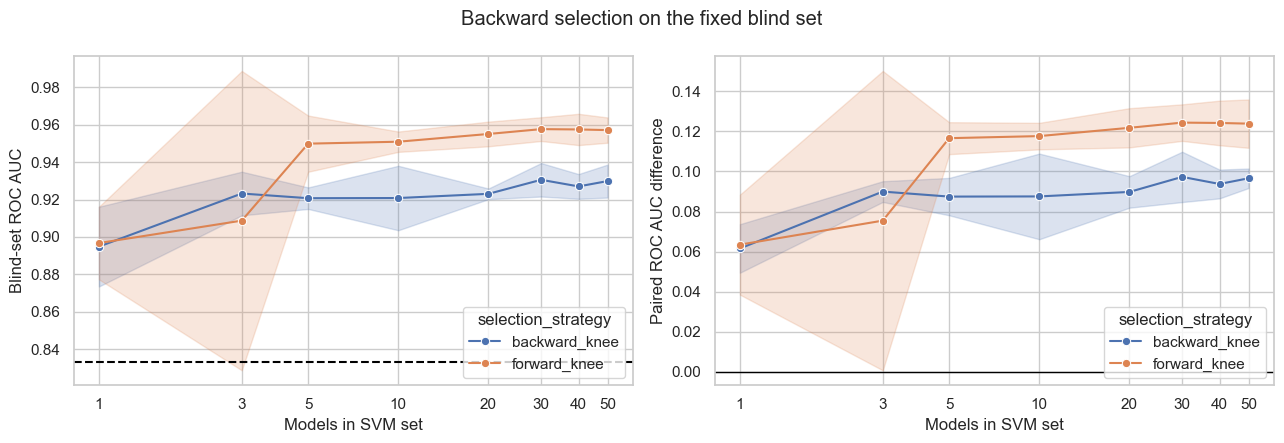

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.lineplot(
    data=paired_auc,
    x="num_models", y="roc_auc", hue="selection_strategy",
    marker="o", errorbar="sd", ax=axes[0],
)
baseline_mean = baseline_auc.mean()
axes[0].axhline(baseline_mean, color="black", linestyle="--", label="sklearn mean")
axes[0].set(xscale="log", xticks=MODEL_COUNTS, xlabel="Models in SVM set", ylabel="Blind-set ROC AUC")
axes[0].get_xaxis().set_major_formatter(plt.ScalarFormatter())

sns.lineplot(
    data=paired_auc,
    x="num_models", y="auc_minus_sklearn", hue="selection_strategy",
    marker="o", errorbar="sd", ax=axes[1],
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(xscale="log", xticks=MODEL_COUNTS, xlabel="Models in SVM set", ylabel="Paired ROC AUC difference")
axes[1].get_xaxis().set_major_formatter(plt.ScalarFormatter())

fig.suptitle("Backward selection on the fixed blind set")
fig.tight_layout()
plt.show()

## Does adding models help relative to one MiSTIC model?

For backward selection, the table subtracts the corresponding
one-model score under the same inner seed. It also reports feature-union size,
signal recovery, and noise fraction so predictive gains can be interpreted
alongside selection behavior.

In [8]:
mistic_results = results.query("method == 'MiSTIC SVM set'").copy()
single_auc = (
    mistic_results.query("num_models == 1")
    .set_index(["selection_strategy", "seed"])["roc_auc"]
)
mistic_results["auc_gain_over_one"] = mistic_results.apply(
    lambda row: row.roc_auc - single_auc.loc[(row.selection_strategy, row.seed)],
    axis=1,
)

gain_summary = (
    mistic_results.groupby(["selection_strategy", "num_models"])
    .agg(
        mean_auc=("roc_auc", "mean"),
        sd_auc=("roc_auc", "std"),
        mean_gain_over_one=("auc_gain_over_one", "mean"),
        sd_gain_over_one=("auc_gain_over_one", "std"),
        mean_member_disagreement=("member_disagreement", "mean"),
        mean_unified_features=("num_unified_features", "mean"),
        mean_signal_recall=("signal_recall", "mean"),
        mean_noise_fraction=("noise_fraction", "mean"),
    )
    .round(4)
)
gain_summary

mean_auc  sd_auc  mean_gain_over_one  \
selection_strategy num_models                                         
backward_knee      1             0.8948  0.0213              0.0000   
                   3             0.9232  0.0117              0.0284   
                   5             0.9207  0.0058              0.0259   
                   10            0.9208  0.0172              0.0260   
                   20            0.9231  0.0028              0.0282   
                   30            0.9306  0.0090              0.0357   
                   40            0.9270  0.0066              0.0322   
                   50            0.9299  0.0088              0.0350   
forward_knee       1             0.8967  0.0194              0.0000   
                   3             0.9087  0.0800              0.0120   
                   5             0.9499  0.0150              0.0531   
                   10            0.9509  0.0054              0.0542   
                   20            0.9551  0.0066              0.0583   
                   30            0.9576  0.0064              0.0609   
                   40            0.9575  0.0084              0.0607   
                   50            0.9571  0.0068              0.0604   

                               sd_gain_over_one  mean_member_disagreement  \
selection_strategy num_models                                               
backward_knee      1                     0.0000                    0.0000   
                   3                     0.0097                    0.1778   
                   5                     0.0173                    0.1749   
                   10                    0.0239                    0.1740   
                   20                    0.0185                    0.1715   
                   30                    0.0182                    0.1662   
                   40                    0.0193                    0.1698   
                   50                    0.0169                    0.1711   
forward_knee       1                     0.0000                    0.0000   
                   3                     0.0989                    0.2684   
                   5                     0.0323                    0.1669   
                   10                    0.0239                    0.2019   
                   20                    0.0260                    0.1907   
                   30                    0.0257                    0.1918   
                   40                    0.0278                    0.1907   
                   50                    0.0260                    0.2000   

                               mean_unified_features  mean_signal_recall  \
selection_strategy num_models                                              
backward_knee      1                         14.0000              0.3833   
                   3                         23.0000              0.4833   
                   5                         26.6667              0.5500   
                   10                        42.3333              0.5667   
                   20                        53.0000              0.6167   
                   30                        67.0000              0.6167   
                   40                        65.3333              0.6000   
                   50                        68.0000              0.6000   
forward_knee       1                          9.3333              0.3000   
                   3                         17.6667              0.4500   
                   5                         24.6667              0.5667   
                   10                        41.3333              0.6333   
                   20                        47.3333              0.6500   
                   30                        53.6667              0.6667   
                   40                        47.6667              0.6667   
                   50                        48.6667              0.6833 

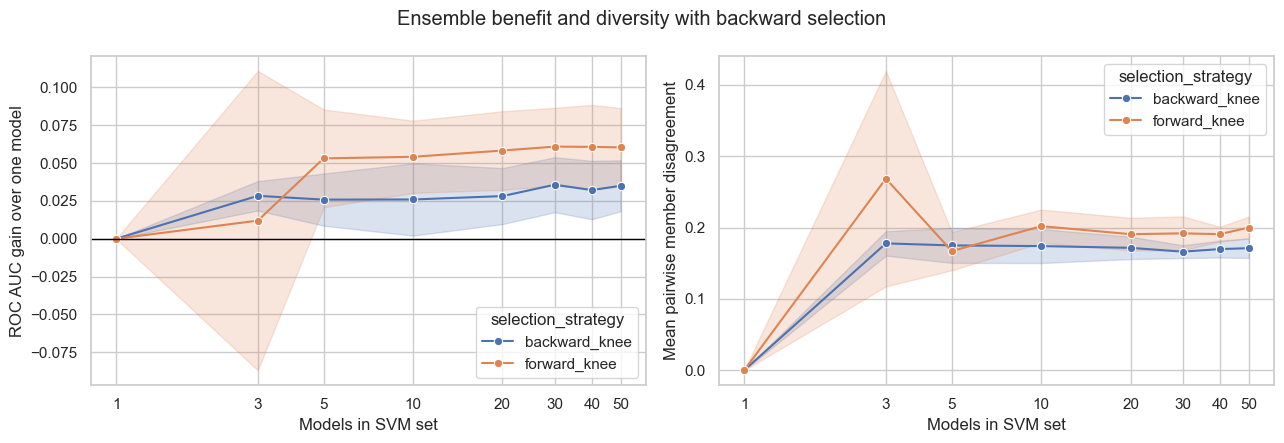

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.lineplot(
    data=mistic_results,
    x="num_models", y="auc_gain_over_one", hue="selection_strategy",
    marker="o", errorbar="sd", ax=axes[0],
)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set(xscale="log", xticks=MODEL_COUNTS, xlabel="Models in SVM set", ylabel="ROC AUC gain over one model")
axes[0].get_xaxis().set_major_formatter(plt.ScalarFormatter())

sns.lineplot(
    data=mistic_results,
    x="num_models", y="member_disagreement", hue="selection_strategy",
    marker="o", errorbar="sd", ax=axes[1],
)
axes[1].set(xscale="log", xticks=MODEL_COUNTS, xlabel="Models in SVM set", ylabel="Mean pairwise member disagreement")
axes[1].get_xaxis().set_major_formatter(plt.ScalarFormatter())

fig.suptitle("Ensemble benefit and diversity with backward selection")
fig.tight_layout()
plt.show()

## Recovery among the top 20 unified features

The complete union can become large when members select separately, so recovery
is evaluated on its 20 highest-ranked features. Features are ordered by
`ensemble.unified_feature_rank`, which averages member-specific ranks, and the
top 20 active union features are retained. `signal_recall` is the fraction of
the 20 known informative or redundant features recovered in that list;
`noise_fraction` is the fraction of the top 20 occupied by known noise
features. The complete union size is still reported separately.

In [10]:
feature_recovery = (
    mistic_results.groupby(["selection_strategy", "num_models"])
    .agg(
        mean_union_size=("num_unified_features", "mean"),
        mean_signal_recall=("signal_recall", "mean"),
        mean_noise_fraction=("noise_fraction", "mean"),
    )
    .round(3)
)
feature_recovery

mean_union_size  mean_signal_recall  \
selection_strategy num_models                                        
backward_knee      1                    14.000               0.383   
                   3                    23.000               0.483   
                   5                    26.667               0.550   
                   10                   42.333               0.567   
                   20                   53.000               0.617   
                   30                   67.000               0.617   
                   40                   65.333               0.600   
                   50                   68.000               0.600   
forward_knee       1                     9.333               0.300   
                   3                    17.667               0.450   
                   5                    24.667               0.567   
                   10                   41.333               0.633   
                   20                   47.333               0.650   
                   30                   53.667               0.667   
                   40                   47.667               0.667   
                   50                   48.667               0.683   

                               mean_noise_fraction  
selection_strategy num_models                       
backward_knee      1                         0.454  
                   3                         0.509  
                   5                         0.450  
                   10                        0.433  
                   20                        0.383  
                   30                        0.383  
                   40                        0.400  
                   50                        0.400  
forward_knee       1                         0.325  
                   3                         0.360  
                   5                         0.362  
                   10                        0.367  
                   20                        0.350  
                   30                        0.333  
                   40                        0.333  
                   50                        0.317

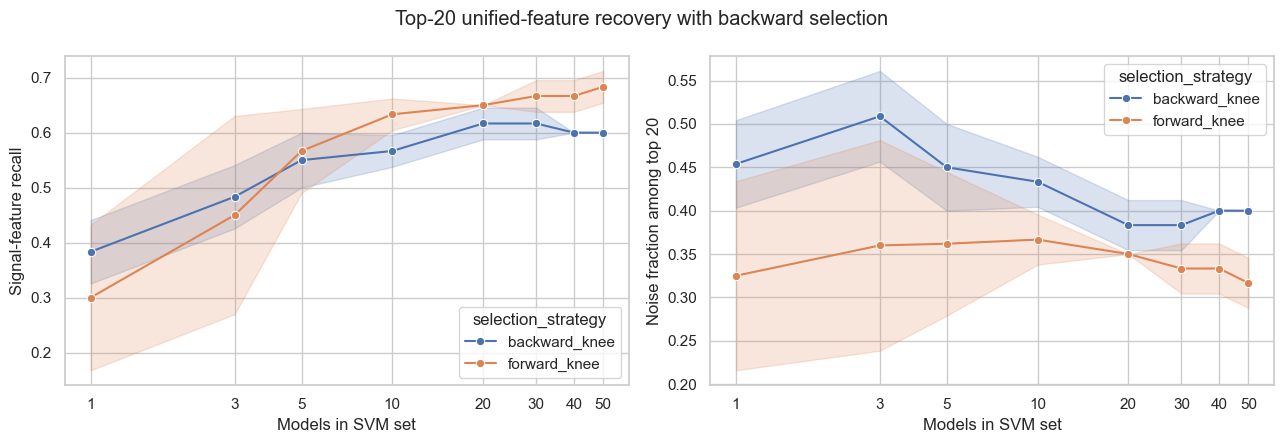

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.lineplot(
    data=mistic_results, x="num_models", y="signal_recall",
    hue="selection_strategy", marker="o", errorbar="sd", ax=axes[0],
)
sns.lineplot(
    data=mistic_results, x="num_models", y="noise_fraction",
    hue="selection_strategy", marker="o", errorbar="sd", ax=axes[1],
)
for ax in axes:
    ax.set_xscale("log")
    ax.set_xticks(MODEL_COUNTS)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes[0].set(xlabel="Models in SVM set", ylabel="Signal-feature recall")
axes[1].set(xlabel="Models in SVM set", ylabel="Noise fraction among top 20")
fig.suptitle("Top-20 unified-feature recovery with backward selection")
fig.tight_layout()
plt.show()

## Standard SVM on the SVM set's unified features

This reference uses the union of the features active in the corresponding SVM
set, but fits one ordinary sklearn SVM on the complete training split. A
positive MiSTIC-minus-reference difference therefore isolates the value of the
set construction from the value of its feature subset. The feature-count
column is included as a check on what the reference actually used.

In [12]:
unified_reference_results = results.query(
    "method == 'sklearn on unified features'"
).copy()

comparison = mistic_results.merge(
    unified_reference_results,
    on=["seed", "selection_strategy", "num_models"],
    suffixes=("_mistic", "_reference"),
)
comparison["auc_minus_unified_reference"] = (
    comparison.roc_auc_mistic - comparison.roc_auc_reference
)

unified_reference_summary = (
    comparison.groupby(["selection_strategy", "num_models"])
    .agg(
        mean_unified_features=("num_unified_features_reference", "mean"),
        mistic_mean_auc=("roc_auc_mistic", "mean"),
        reference_mean_auc=("roc_auc_reference", "mean"),
        mean_auc_difference=("auc_minus_unified_reference", "mean"),
        sd_auc_difference=("auc_minus_unified_reference", "std"),
    )
    .round(4)
)
unified_reference_summary

mean_unified_features  mistic_mean_auc  \
selection_strategy num_models                                           
backward_knee      1                         14.0000           0.8948   
                   3                         23.0000           0.9232   
                   5                         26.6667           0.9207   
                   10                        42.3333           0.9208   
                   20                        53.0000           0.9231   
                   30                        67.0000           0.9306   
                   40                        65.3333           0.9270   
                   50                        68.0000           0.9299   
forward_knee       1                          9.3333           0.8967   
                   3                         17.6667           0.9087   
                   5                         24.6667           0.9499   
                   10                        41.3333           0.9509   
                   20                        47.3333           0.9551   
                   30                        53.6667           0.9576   
                   40                        47.6667           0.9575   
                   50                        48.6667           0.9571   

                               reference_mean_auc  mean_auc_difference  \
selection_strategy num_models                                            
backward_knee      1                       0.9014              -0.0066   
                   3                       0.8988               0.0244   
                   5                       0.9124               0.0084   
                   10                      0.8905               0.0303   
                   20                      0.8639               0.0592   
                   30                      0.8696               0.0610   
                   40                      0.8602               0.0669   
                   50                      0.8649               0.0650   
forward_knee       1                       0.8973              -0.0005   
                   3                       0.9237              -0.0149   
                   5                       0.9274               0.0225   
                   10                      0.8991               0.0518   
                   20                      0.8956               0.0594   
                   30                      0.8939               0.0638   
                   40                      0.9123               0.0452   
                   50                      0.8960               0.0611   

                               sd_auc_difference  
selection_strategy num_models                     
backward_knee      1                      0.0153  
                   3                      0.0232  
                   5                      0.0198  
                   10                     0.0148  
                   20                     0.0127  
                   30                     0.0067  
                   40                     0.0098  
                   50                     0.0164  
forward_knee       1                      0.0053  
                   3                      0.0614  
                   5                      0.0227  
                   10                     0.0135  
                   20                     0.0133  
                   30                     0.0023  
                   40                     0.0295  
                   50                     0.0205

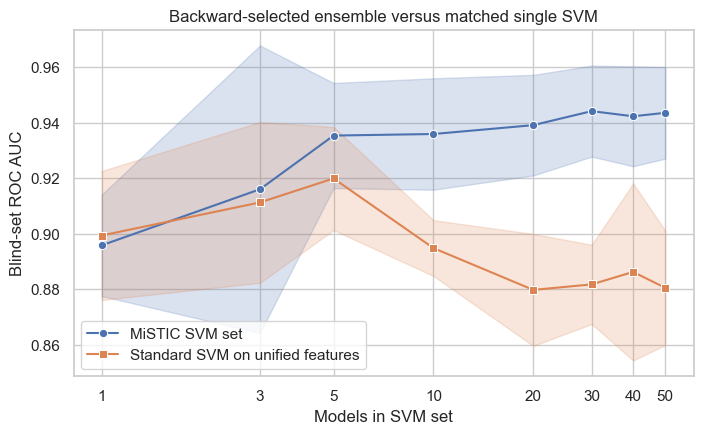

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(
    data=mistic_results,
    x="num_models", y="roc_auc", marker="o", errorbar="sd",
    ax=ax, label="MiSTIC SVM set",
)
sns.lineplot(
    data=unified_reference_results,
    x="num_models", y="roc_auc", marker="s", errorbar="sd",
    ax=ax, label="Standard SVM on unified features",
)
ax.set(
    xscale="log", xticks=MODEL_COUNTS,
    xlabel="Models in SVM set", ylabel="Blind-set ROC AUC",
    title="Backward-selected ensemble versus matched single SVM",
)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
plt.show()

## Stability and diminishing returns

Performance alone can hide whether a set is becoming more stable. Here the standard deviation across inner seeds measures sensitivity to model construction while the training and blind rows remain fixed. The marginal-gain table compares each tested size with the preceding size; this helps identify where more members stop buying meaningful improvement.

In [14]:
size_curve = (
    mistic_results.groupby(["selection_strategy", "num_models"])["roc_auc"]
    .agg(mean_auc="mean", sd_auc="std")
)
size_curve["gain_from_previous_size"] = (
    size_curve.groupby(level="selection_strategy")["mean_auc"].diff()
)
size_curve.round(4)

mean_auc  sd_auc  gain_from_previous_size
selection_strategy num_models                                           
backward_knee      1             0.8948  0.0213                      NaN
                   3             0.9232  0.0117                   0.0284
                   5             0.9207  0.0058                  -0.0025
                   10            0.9208  0.0172                   0.0001
                   20            0.9231  0.0028                   0.0022
                   30            0.9306  0.0090                   0.0075
                   40            0.9270  0.0066                  -0.0035
                   50            0.9299  0.0088                   0.0028
forward_knee       1             0.8967  0.0194                      NaN
                   3             0.9087  0.0800                   0.0120
                   5             0.9499  0.0150                   0.0411
                   10            0.9509  0.0054                   0.0010
                   20            0.9551  0.0066                   0.0041
                   30            0.9576  0.0064                   0.0026
                   40            0.9575  0.0084                  -0.0002
                   50            0.9571  0.0068                  -0.0003

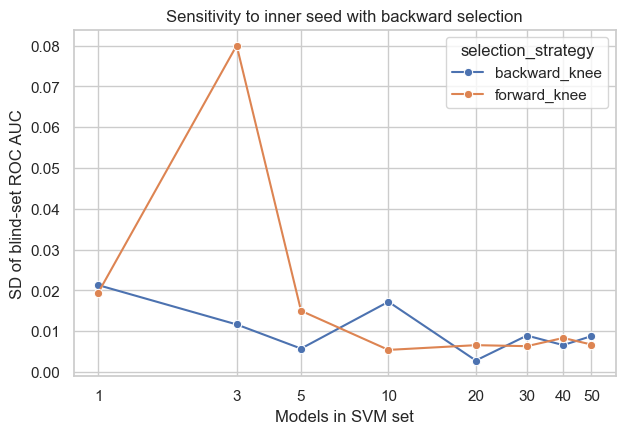

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.lineplot(
    data=size_curve.reset_index(),
    x="num_models", y="sd_auc", hue="selection_strategy", marker="o", ax=ax,
)
ax.set(
    xscale="log",
    xticks=MODEL_COUNTS,
    xlabel="Models in SVM set",
    ylabel="SD of blind-set ROC AUC",
    title="Sensitivity to inner seed with backward selection",
)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
plt.show()

## Interpretation checklist

- Compare forward-knee and backward-knee at the same ensemble size.
- Compare each knee-selected set with its matched sklearn unified-feature model.
- RFE provides a conventional fixed-20-feature reference; the all-feature pipeline provides the no-selection reference.
- The known-signal oracle uses generator truth and is an upper bound, not a deployable selector.
- Top-20 signal recall measures ranking quality even when separate member subsets create a larger union.
- Look for performance plateaus as model count increases from 1 to 50.

Only the new knee-selected default is displayed. Search-selected maximum-score
subsets are omitted from the comparison.

## Consolidated comparison with all reference methods

This table combines the post-retune MiSTIC sets with the standard sklearn
references, sklearn SVM + RFE, and the known-signal oracle. The oracle and RFE
each use 20 features, but only the oracle is given their true identities. MiSTIC
recovery is measured among its top 20 unified features. The unified-feature
sklearn model is trained on the complete MiSTIC union; its recovery columns
describe the originating MiSTIC top-20 ranking, while `mean_feature_count`
shows how many union features the reference actually receives. The all-feature
pipeline has no selected-feature recovery metric. The oracle's perfect recovery
is true by construction. All methods use the same
fixed blind set and three inner seeds.

In [16]:
blind_feature_comparison = (
    results.query(
        "method in ['MiSTIC SVM set', 'sklearn pipeline', "
        "'sklearn SVM + RFE', 'sklearn on unified features', "
        "'sklearn oracle: known signal']"
    )
    .groupby(["method", "selection_strategy", "num_models"])
    .agg(
        mean_auc=("roc_auc", "mean"),
        sd_auc=("roc_auc", "std"),
        mean_f1=("f1", "mean"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        mean_accuracy=("accuracy", "mean"),
        mean_feature_count=("num_unified_features", "mean"),
        mean_signal_recall=("signal_recall", "mean"),
        mean_noise_fraction=("noise_fraction", "mean"),
    )
    .round(4)
)
blind_feature_comparison

mean_auc  \
method                       selection_strategy    num_models             
MiSTIC SVM set               backward_knee         1             0.8948   
                                                   3             0.9232   
                                                   5             0.9207   
                                                   10            0.9208   
                                                   20            0.9231   
                                                   30            0.9306   
                                                   40            0.9270   
                                                   50            0.9299   
                             forward_knee          1             0.8967   
                                                   3             0.9087   
                                                   5             0.9499   
                                                   10            0.9509   
                                                   20            0.9551   
                                                   30            0.9576   
                                                   40            0.9575   
                                                   50            0.9571   
sklearn SVM + RFE            RFE                   1             0.8879   
sklearn on unified features  backward_knee         1             0.9014   
                                                   3             0.8988   
                                                   5             0.9124   
                                                   10            0.8905   
                                                   20            0.8639   
                                                   30            0.8696   
                                                   40            0.8602   
                                                   50            0.8649   
                             forward_knee          1             0.8973   
                                                   3             0.9237   
                                                   5             0.9274   
                                                   10            0.8991   
                                                   20            0.8956   
                                                   30            0.8939   
                                                   40            0.9123   
                                                   50            0.8960   
sklearn oracle: known signal known signal (oracle) 1             0.9723   
sklearn pipeline             all features          1             0.8332   

                                                               sd_auc  \
method                       selection_strategy    num_models           
MiSTIC SVM set               backward_knee         1           0.0213   
                                                   3           0.0117   
                                                   5           0.0058   
                                                   10          0.0172   
                                                   20          0.0028   
                                                   30          0.0090   
                                                   40          0.0066   
                                                   50          0.0088   
                             forward_knee          1           0.0194   
                                                   3           0.0800   
                                                   5           0.0150   
                                                   10          0.0054   
                                                   20          0.0066   
                                                   30          0.0064   
                                                   40          0.0084   
                                              

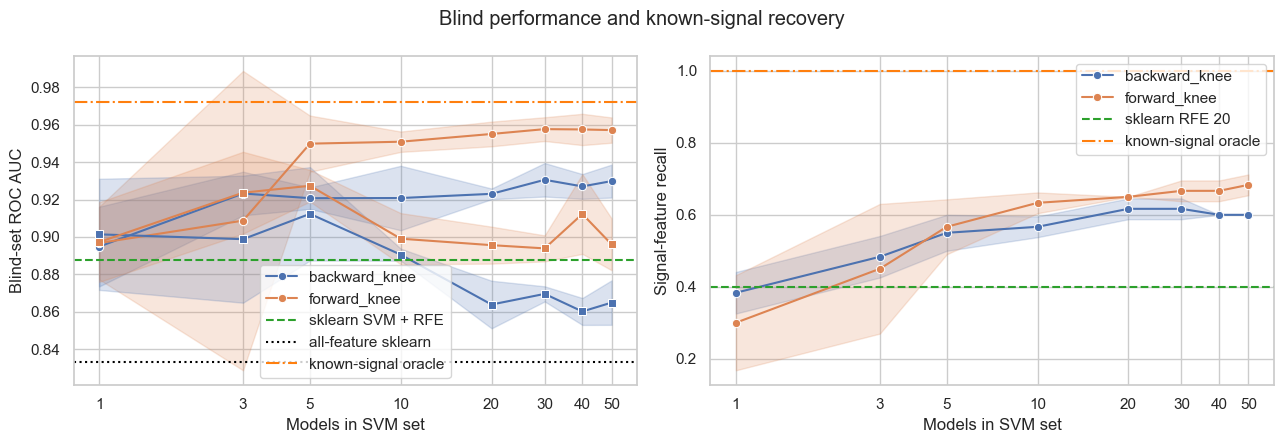

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

mistic_plot = mistic_results.copy()
sns.lineplot(
    data=mistic_plot, x="num_models", y="roc_auc",
    hue="selection_strategy", marker="o", errorbar="sd", ax=axes[0],
)
unified_plot = unified_reference_results.copy()
sns.lineplot(
    data=unified_plot, x="num_models", y="roc_auc",
    hue="selection_strategy", marker="s", errorbar="sd", ax=axes[0],
    legend=False,
)
rfe_auc = rfe_results.roc_auc.mean()
oracle_results = results.query("method == 'sklearn oracle: known signal'")
oracle_auc = oracle_results.roc_auc.mean()
axes[0].axhline(rfe_auc, color="tab:green", linestyle="--", label="sklearn SVM + RFE")
axes[0].axhline(baseline_auc.mean(), color="black", linestyle=":", label="all-feature sklearn")
axes[0].axhline(oracle_auc, color="tab:orange", linestyle="-.", label="known-signal oracle")
axes[0].set(xscale="log", xticks=MODEL_COUNTS, xlabel="Models in SVM set", ylabel="Blind-set ROC AUC")
axes[0].get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes[0].legend()

sns.lineplot(
    data=mistic_plot, x="num_models", y="signal_recall",
    hue="selection_strategy", marker="o", errorbar="sd", ax=axes[1],
)
axes[1].axhline(rfe_results.signal_recall.mean(), color="tab:green", linestyle="--", label="sklearn RFE 20")
axes[1].axhline(1.0, color="tab:orange", linestyle="-.", label="known-signal oracle")
axes[1].set(xscale="log", xticks=MODEL_COUNTS, xlabel="Models in SVM set", ylabel="Signal-feature recall")
axes[1].get_xaxis().set_major_formatter(plt.ScalarFormatter())
axes[1].legend()

fig.suptitle("Blind performance and known-signal recovery")
fig.tight_layout()
plt.show()